In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv.imread('./images/someshapes.jpg')
img.shape

(800, 1000, 3)

In [4]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray.shape

(800, 1000)

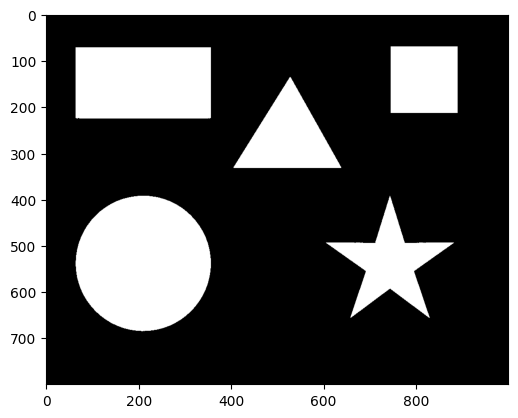

In [39]:
ret, dst = cv.threshold(gray, 127, 255, cv.THRESH_BINARY_INV)
plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB));

In [18]:
contours, hierarchy = cv.findContours(dst, cv.RETR_TREE, cv.CHAIN_APPROX_NONE)

In [41]:
len(contours)

5

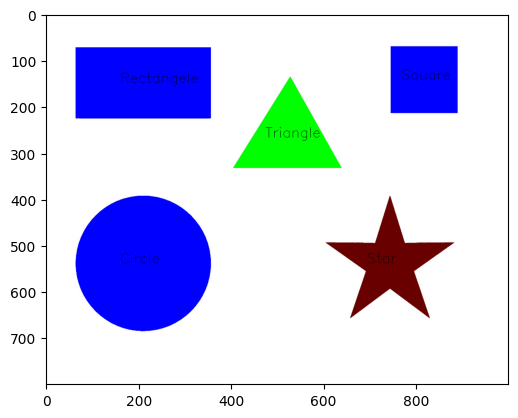

In [45]:
for contour in contours:
    vertices = cv.approxPolyDP(contour, 0.01*cv.arcLength(contour, True), True)

    if len(vertices) == 3:
        cv.drawContours(img, [contour], 0, (0, 255, 0), -1)
        M = cv.moments(contour)
        x = int(M['m10']/M['m00'])
        y = int(M['m01']/M['m00'])
        cv.putText(img, 'Triangle', (x-50, y), cv.FONT_ITALIC, 1,(0,0,0), 1)

    elif len(vertices) == 5:
        cv.drawContours(img, [contour], 0, (105,0,105), -1)	
        M = cv.moments(contour)
        x = int(M['m10']/M['m00'])
        y = int(M['m01']/M['m00'])
        cv.putText(img, 'Pentagon', (x-50, y), cv.FONT_ITALIC, 1,(0,0,0), 1)


    elif len(vertices) == 8 or len(vertices) == 10:
        cv.drawContours(img, [contour], 0, (0,0,105), -1)
        M = cv.moments(contour)
        x = int(M['m10']/M['m00'])
        y = int(M['m01']/M['m00'])
        cv.putText(img, 'Star', (x-50, y), cv.FONT_ITALIC, 1,(0,0,0), 1)

    elif len(vertices) >= 12:
        cv.drawContours(img, [contour], 0, (255,0,0), -1)
        M = cv.moments(contour)
        x = int(M['m10']/M['m00'])
        y = int(M['m01']/M['m00'])
        cv.putText(img, 'Circle', (x-50, y), cv.FONT_ITALIC, 1,(0,0,0), 1)

    elif len(vertices) == 4:
        M = cv.moments(contour)
        x = int(M['m10']/M['m00'])
        y = int(M['m01']/M['m00'])
        x0, y0, width, height = cv.boundingRect(contour)
        if abs(width - height) <=3:
            cv.drawContours(img, [contour], 0, (255,0,0), -1)
            cv.putText(img, 'Square', (x-50, y), cv.FONT_ITALIC, 1,(0,0,0), 1)
        else:
            cv.drawContours(img, [contour], 0, (255,0,0), -1)
            cv.putText(img, 'Rectangele', (x-50, y), cv.FONT_ITALIC, 1,(0,0,0), 1)


plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))